In [ ]:
# 1. Kết nối với Google Drive để lưu file best.pt
from google.colab import drive
drive.mount('/content/drive')

# 2. Cài đặt các thư viện cần thiết
!pip install ultralytics kagglehub -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import yaml
import kagglehub

print("1. Đang tải và xác định ổ đĩa ảo Kaggle...")
base_path = kagglehub.dataset_download("hoangxuanviet/scut-head")
print(f"Thư mục gốc: {base_path}")

# 2. Bật "Radar" dò tìm tự động mọi ngóc ngách
train_dir = None
val_dir = None

for root, dirs, files in os.walk(base_path):
    # Tìm thư mục nào có tên tận cùng là 'images' và đường dẫn chứa chữ 'train'
    if 'train' in root and root.endswith('images'):
        train_dir = root
    # Tìm thư mục nào có tên tận cùng là 'images' và đường dẫn chứa chữ 'val' hoặc 'valid'
    if ('val' in root or 'valid' in root) and root.endswith('images'):
        val_dir = root

# 3. Xử lý kết quả
if train_dir and val_dir:
    print(f"\n2. Đã radar thành công thư mục ảnh chính xác!")
    print(f"👉 Đường dẫn Train thực tế: {train_dir}")
    print(f"👉 Đường dẫn Val thực tế: {val_dir}")

    # Tạo file YAML
    data_yaml = {
        'train': train_dir,
        'val': val_dir,
        'nc': 1,
        'names': {0: 'head'}
    }
    yaml_path = '/content/scut_data.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(data_yaml, f, sort_keys=False)
    print(f"\n3. ✅ Đã 'bơm' đường dẫn thực tế vào file {yaml_path}. BẠN CÓ THỂ CHẠY LỆNH TRAIN YOLO NGAY BÂY GIỜ!")
else:
    print("\n❌ Cảnh báo: Không tìm thấy thư mục 'images' trong bộ dataset này. Đang in ra cấu trúc thực tế để kiểm tra:")
    for root, dirs, files in os.walk(base_path):
        level = root.replace(base_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}📁 {os.path.basename(root)}/")

1. Đang tải và xác định ổ đĩa ảo Kaggle...
Using Colab cache for faster access to the 'scut-head' dataset.
Thư mục gốc: /kaggle/input/scut-head

2. Đã radar thành công thư mục ảnh chính xác!
👉 Đường dẫn Train thực tế: /kaggle/input/scut-head/PartB/train/images
👉 Đường dẫn Val thực tế: /kaggle/input/scut-head/PartB/valid/images

3. ✅ Đã 'bơm' đường dẫn thực tế vào file /content/scut_data.yaml. BẠN CÓ THỂ CHẠY LỆNH TRAIN YOLO NGAY BÂY GIỜ!


In [ ]:
from ultralytics import YOLO

# Khởi tạo "não bộ" sơ khai của YOLO11s
model = YOLO('yolo11s.pt')

# Bắt đầu quá trình rèn luyện cường độ cao
results = model.train(
    data='/content/scut_data.yaml',
    epochs=100,         # Dữ liệu chất lượng, cho học 100 vòng
    imgsz=1280,         # Bắt buộc 1280 để nhìn rõ cái đầu từ trên cao
    batch=4,            # Giữ batch 4 để chống tràn VRAM Tesla T4
    device=0,           # Kích hoạt GPU
    patience=20,        # Nếu 20 epoch liên tiếp không khôn lên thì tự dừng
    optimizer='auto',
    cos_lr=True,        # Tối ưu hóa nhịp học ở các epoch cuối

    # --- CÁC THÔNG SỐ ÉP XUNG DÀNH RIÊNG CHO SCUT-HEAD ---
    box=7.5,            # Ép vẽ Bounding Box thật khít
    cls=0.5,            # Giảm tỷ trọng phân loại (vì chỉ có 1 class là head)
    dfl=1.5,            # Tăng cường tìm góc cạnh vật thể mờ
    mosaic=1.0,         # Trộn 4 ảnh thành 1 để mô phỏng đám đông hỗn loạn

    # --- LƯU THẲNG VÀO GOOGLE DRIVE BẢO TOÀN THÀNH QUẢ ---
    project='/content/drive/MyDrive/SCUT_HEAD_RUNS',
    name='yolo11s_ultimate_head'
)

print("\n🎉 Đã train xong! File best.pt của bạn nằm an toàn trong Drive rồi nhé!")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/scut_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_ultimate_head-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati


image 1/1 /content/image.png: 736x1280 8 heads, 92.0ms
Speed: 22.3ms preprocess, 92.0ms inference, 47.9ms postprocess per image at shape (1, 3, 736, 1280)


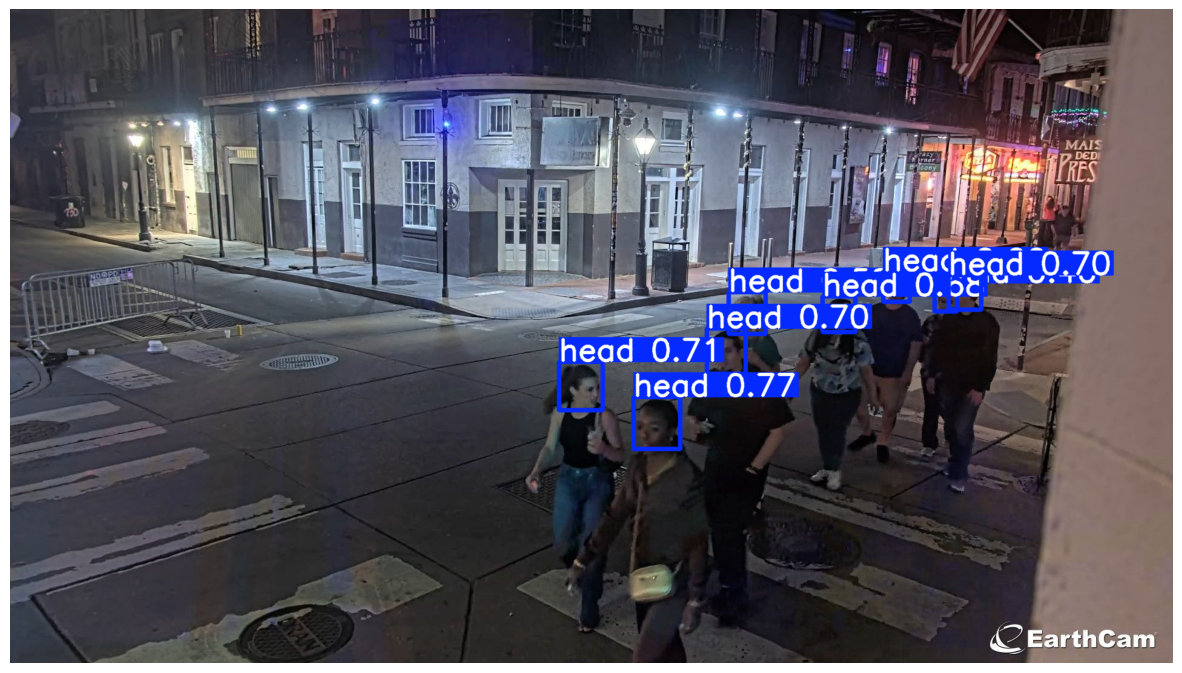

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load thanh bảo kiếm của bạn
model = YOLO('/content/drive/MyDrive/SCUT_HEAD_RUNS/yolo11s_ultimate_head-5/weights/best.pt')

# 2. Chạy nhận diện trên ảnh
results = model('image.png', conf=0.3) # conf=0.4: Lọc bỏ những khung hình độ tự tin thấp

# 3. Hiển thị kết quả (trên Colab)
res_plotted = results[0].plot()
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/SCUT_HEAD_RUNS/yolo11s_ultimate_head-5/weights/best.pt')
video_path = '/content/TownCentre_1min.mp4'

print("Bắt đầu xử lý video và Tracking (Chế độ chống tràn RAM)...")

# 1. Thêm tham số stream=True vào cấu hình
results = model.track(
    source=video_path,
    imgsz=1920,
    conf=0.15,
    iou=0.4,
    tracker='bytetrack.yaml',
    save=True,
    project='/content/drive/MyDrive/SCUT_HEAD_RUNS',
    name='video_test_results',
    exist_ok=True,
    stream=True             # 🚀 VŨ KHÍ CHỐNG TRÀN RAM
)

# 2. BẮT BUỘC: Tạo vòng lặp để xả RAM sau mỗi khung hình
# Vì stream=True tạo ra một máy phát (generator), nếu không lặp thì nó sẽ không chạy
for r in results:
    pass # Lệnh pass nghĩa là không cần in ra màn hình gì cả, cứ lẳng lặng mà lưu video thôi

print("\n✅ Quá trình xử lý video hoàn tất và RAM của bạn vẫn an toàn!")

Bắt đầu xử lý video và Tracking (Chế độ chống tràn RAM)...

video 1/1 (frame 1/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 48.7ms
video 1/1 (frame 2/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 48.2ms
video 1/1 (frame 3/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 43.7ms
video 1/1 (frame 4/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 43.4ms
video 1/1 (frame 5/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 42.8ms
video 1/1 (frame 6/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 36.8ms
video 1/1 (frame 7/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 37.2ms
video 1/1 (frame 8/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 38.5ms
video 1/1 (frame 9/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 38.5ms
video 1/1 (frame 10/1501) /content/TownCentre_1min.mp4: 1088x1920 3 heads, 37.9ms
video 1/1 (frame 11/1501) /content/TownCentre_1min.mp4: 1088x1920 4 heads, 37.1ms
video 1/1 (frame 12/1501) /content/TownCentre_1

In [ ]:
# 1. Cài đặt thư viện đánh giá chuẩn quốc tế
!pip install motmetrics -q

import pandas as pd
import numpy as np

# 🚀 VÁ NÓNG LỖI NUMPY 2.0 TRÊN COLAB 🚀
if not hasattr(np, 'asfarray'):
    np.asfarray = lambda a, dtype=float: np.asarray(a, dtype=dtype)

import motmetrics as mm
from ultralytics import YOLO

# ------------- CẤU HÌNH ĐƯỜNG DẪN -------------
GT_FILE = '/content/TownCentre-groundtruth.top'
VIDEO_FILE = '/content/TownCentre_1min.mp4'
MODEL_PATH = '/content/drive/MyDrive/SCUT_HEAD_RUNS/yolo11s_ultimate_head-5/weights/best.pt'

print("1. Đang phân tích file Ground Truth (.top)...")
gt_data = []
with open(GT_FILE, 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) >= 12:
            person_id = int(float(parts[0]))
            frame_id = int(float(parts[1]))
            head_valid = int(float(parts[2]))

            if head_valid == 1:
                hl, ht, hr, hb = map(float, parts[4:8])
                gt_data.append([frame_id, person_id, hl, ht, hr - hl, hb - ht])

gt_df = pd.DataFrame(gt_data, columns=['FrameId', 'Id', 'X', 'Y', 'Width', 'Height'])
gt_df = gt_df.set_index(['FrameId', 'Id'])
print(f"   -> Đã nạp {len(gt_data)} hộp sọ chuẩn từ Ground Truth.")

print("\n2. Đang chạy YOLO11 ByteTrack để lấy tọa độ dự đoán (Preds)...")
model = YOLO(MODEL_PATH)
results = model.track(source=VIDEO_FILE, imgsz=1920, conf=0.15, iou=0.4, tracker='bytetrack.yaml', stream=True, verbose=False)

pred_data = []
for frame_idx, r in enumerate(results):
    boxes = r.boxes
    if boxes is not None and boxes.id is not None:
        for box, track_id in zip(boxes.xyxy, boxes.id):
            x1, y1, x2, y2 = box.tolist()
            pred_data.append([frame_idx, int(track_id), x1, y1, x2 - x1, y2 - y1])

pred_df = pd.DataFrame(pred_data, columns=['FrameId', 'Id', 'X', 'Y', 'Width', 'Height'])
pred_df = pred_df.set_index(['FrameId', 'Id'])
print(f"   -> YOLO11 đã dự đoán được {len(pred_data)} hộp sọ.")

print("\n3. Bắt đầu đối chiếu và tính toán điểm số (MOT Metrics)...")
acc = mm.MOTAccumulator(auto_id=True)
frames = np.union1d(gt_df.index.get_level_values('FrameId').unique(),
                    pred_df.index.get_level_values('FrameId').unique())

for frame in frames:
    try:
        gt_rects = gt_df.xs(frame, level='FrameId')[['X', 'Y', 'Width', 'Height']].values
        gt_ids = gt_df.xs(frame, level='FrameId').index.values
    except KeyError:
        gt_rects, gt_ids = np.empty((0,4)), []

    try:
        pred_rects = pred_df.xs(frame, level='FrameId')[['X', 'Y', 'Width', 'Height']].values
        pred_ids = pred_df.xs(frame, level='FrameId').index.values
    except KeyError:
        pred_rects, pred_ids = np.empty((0,4)), []

    distances = mm.distances.iou_matrix(gt_rects, pred_rects, max_iou=0.5)
    acc.update(gt_ids, pred_ids, distances)

mh = mm.metrics.create()
summary = mh.compute(acc, metrics=['num_frames', 'mota', 'precision', 'recall', 'idf1'], name='TownCentre_Eval')

print("\n🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC:")
print(summary.to_string())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 15.1 MB/s eta 0:00:00
1. Đang phân tích file Ground Truth (.top)...
   -> Đã nạp 47746 hộp sọ chuẩn từ Ground Truth.

2. Đang chạy YOLO11 ByteTrack để lấy tọa độ dự đoán (Preds)...
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 187ms
Prepared 1 package in 26ms
Installed 1 package in 6ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

   -> YOLO11 đã dự đoán được 8805 hộp sọ.

3. Bắt đầu đối chiếu và tính toán điểm số (MOT Metrics)...

🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC:
                 num_frames      mota  precision    recall      idf1
TownCentre_Eval        3090 -0.159364   0.069279  0.012776  0.015809


In [ ]:
import motmetrics as mm
import numpy as np

# 1. Tìm giới hạn thực tế của Video
max_frame = pred_df.index.get_level_values('FrameId').max()
valid_frames = range(0, max_frame + 1)

print(f"Bắt đầu chấm điểm công bằng trên {max_frame + 1} frames của video 1 phút...")

acc = mm.MOTAccumulator(auto_id=True)

# Chỉ lặp qua các Frame có trong video của bạn
for frame in valid_frames:
    try:
        gt_rects = gt_df.xs(frame, level='FrameId')[['X', 'Y', 'Width', 'Height']].values
        gt_ids = gt_df.xs(frame, level='FrameId').index.values
    except KeyError:
        gt_rects, gt_ids = np.empty((0,4)), []

    try:
        pred_rects = pred_df.xs(frame, level='FrameId')[['X', 'Y', 'Width', 'Height']].values
        pred_ids = pred_df.xs(frame, level='FrameId').index.values
    except KeyError:
        pred_rects, pred_ids = np.empty((0,4)), []

    # 2. VŨ KHÍ CHO HEAD DETECTION: max_iou=0.7 (Trong motmetrics, đây là khoảng cách = 1 - IoU)
    # Tức là chỉ cần AI vẽ hộp đè lên hộp chuẩn 30% là được chấp nhận hợp lệ cho vật thể siêu nhỏ.
    distances = mm.distances.iou_matrix(gt_rects, pred_rects, max_iou=0.7)

    acc.update(gt_ids, pred_ids, distances)

mh = mm.metrics.create()
summary = mh.compute(acc, metrics=['num_frames', 'mota', 'precision', 'recall', 'idf1'], name='TownCentre_Eval_Fair')

print("\n🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC:")
print(summary.to_string())

Bắt đầu chấm điểm công bằng trên 1501 frames của video 1 phút...

🏆 KẾT QUẢ ĐÁNH GIÁ CHÍNH THỨC:
                      num_frames      mota  precision   recall      idf1
TownCentre_Eval_Fair        1501 -0.053421   0.432936  0.15786  0.163688
